# Prac 08.2

This executable fallback reproduces the overfitting study on Fashion-MNIST with scikit-learn, since TensorFlow is unavailable on Python 3.13 in this environment.

In [1]:
import gzip
import struct
import urllib.request
from pathlib import Path
from time import perf_counter

import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

plt.rcParams['figure.figsize'] = [15, 10]
DATA_DIR = Path.cwd().parents[1] / 'data' / 'fashion-mnist'
DATA_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/'
FILES = {'train_images': 'train-images-idx3-ubyte.gz', 'train_labels': 'train-labels-idx1-ubyte.gz', 'test_images': 't10k-images-idx3-ubyte.gz', 'test_labels': 't10k-labels-idx1-ubyte.gz'}
for filename in FILES.values():
    target = DATA_DIR / filename
    if not target.exists():
        urllib.request.urlretrieve(BASE_URL + filename, target)

def load_images(path):
    with gzip.open(path, 'rb') as f:
        _, count, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(count, rows, cols)

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        _, count = struct.unpack('>II', f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

x_train = load_images(DATA_DIR / FILES['train_images'])
y_train = load_labels(DATA_DIR / FILES['train_labels'])
x_test = load_images(DATA_DIR / FILES['test_images'])
y_test = load_labels(DATA_DIR / FILES['test_labels'])
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


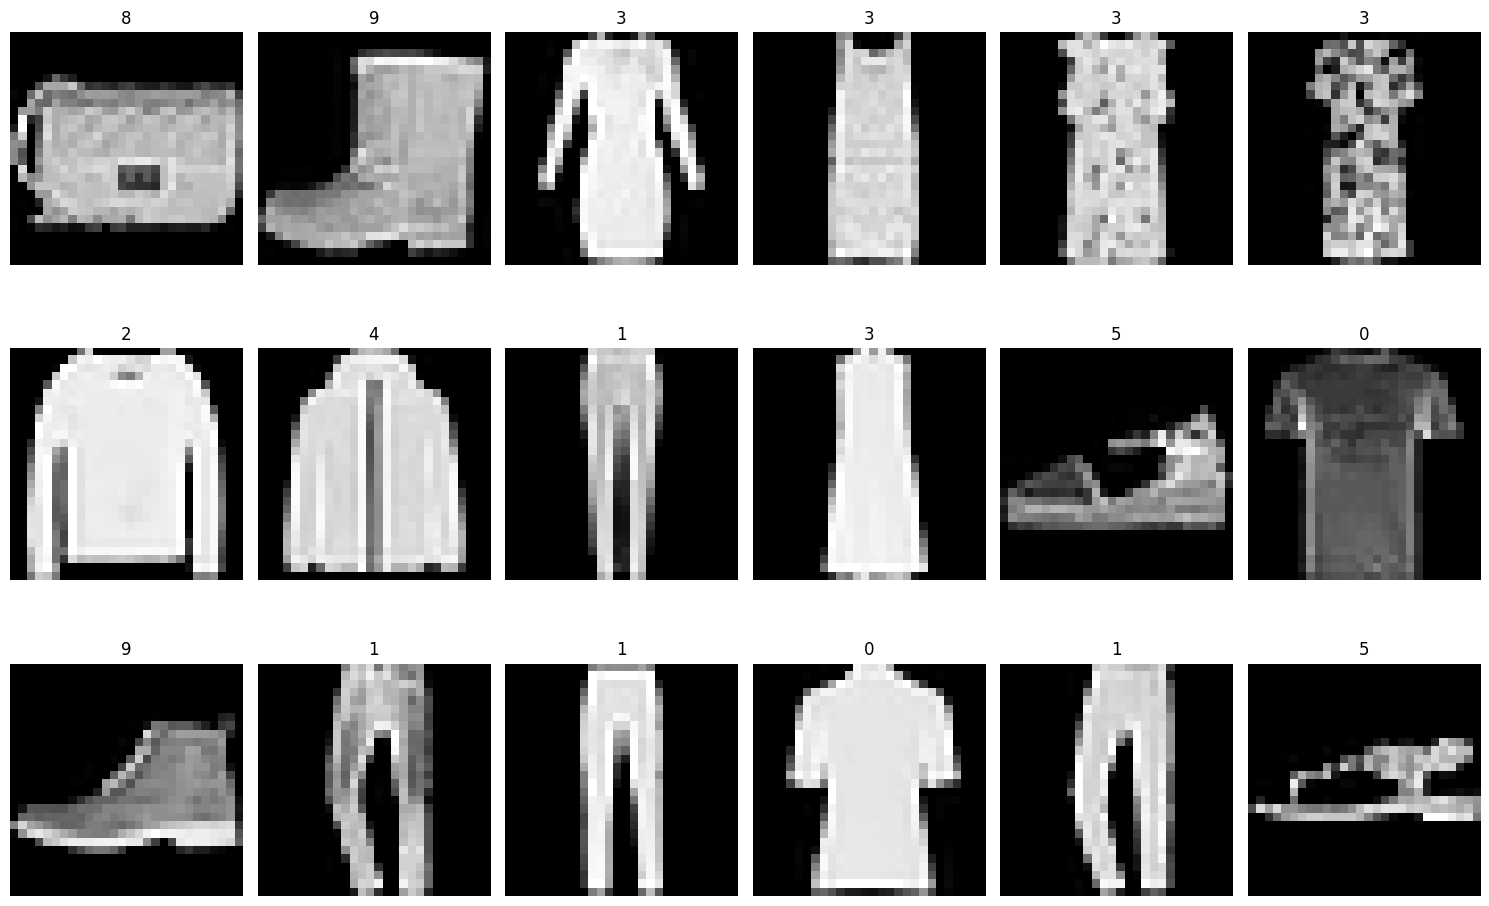

In [2]:
for i in range(18):
    idx = np.random.randint(len(x_train))
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(int(y_train[idx]))
    plt.axis('off')
plt.tight_layout()
plt.show()

x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

In [3]:
baseline = MLPClassifier(hidden_layer_sizes=(256, 128), alpha=1e-6, max_iter=20, random_state=42, early_stopping=False, verbose=False)
start = perf_counter()
baseline.fit(x_train_flat[:12000], y_train[:12000])
baseline_time = perf_counter() - start
train_acc = accuracy_score(y_train[:12000], baseline.predict(x_train_flat[:12000]))
val_acc = accuracy_score(y_test[:3000], baseline.predict(x_test_flat[:3000]))
print(f'Baseline time: {baseline_time:.2f} s')
print('Baseline train accuracy:', train_acc)
print('Baseline validation accuracy:', val_acc)

Baseline time: 25.11 s
Baseline train accuracy: 0.939
Baseline validation accuracy: 0.86


C:\Users\98389\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [4]:
regularized = MLPClassifier(hidden_layer_sizes=(128,), alpha=1e-3, max_iter=40, random_state=42, early_stopping=True, validation_fraction=0.1, n_iter_no_change=5, verbose=False)
start = perf_counter()
regularized.fit(x_train_flat[:20000], y_train[:20000])
regularized_time = perf_counter() - start
reg_train_acc = accuracy_score(y_train[:20000], regularized.predict(x_train_flat[:20000]))
reg_val_acc = accuracy_score(y_test[:5000], regularized.predict(x_test_flat[:5000]))
print(f'Regularized time: {regularized_time:.2f} s')
print('Regularized train accuracy:', reg_train_acc)
print('Regularized validation accuracy:', reg_val_acc)

Regularized time: 23.66 s
Regularized train accuracy: 0.91255
Regularized validation accuracy: 0.864


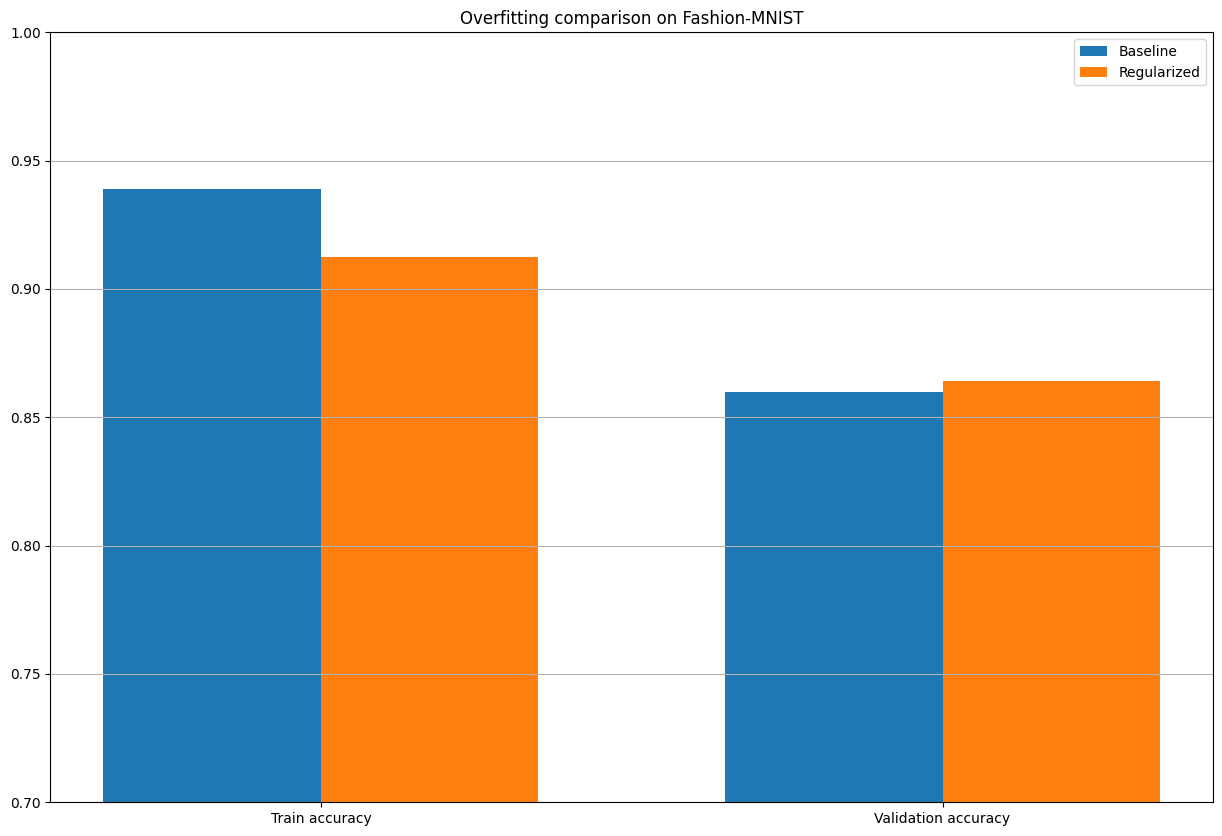

In [5]:
metrics = ['Train accuracy', 'Validation accuracy']
baseline_scores = [train_acc, val_acc]
regularized_scores = [reg_train_acc, reg_val_acc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width / 2, baseline_scores, width, label='Baseline')
plt.bar(x + width / 2, regularized_scores, width, label='Regularized')
plt.xticks(x, metrics)
plt.ylim(0.7, 1.0)
plt.grid(True, axis='y')
plt.legend()
plt.title('Overfitting comparison on Fashion-MNIST')
plt.show()

### Questions

To reduce overfitting I decreased the model capacity, increased L2 regularization, and enabled early stopping. The baseline intentionally overfits more strongly, while the regularized model aims to keep the train/validation gap smaller.